In [1]:
"""
my prediction_file is like /niddk-data-central/leo_workspace/iwatch_W/val_result/zeroshot_prediction/CHAP_ALL_ADULTS/i0001A.csv
each csv file looks like:
segment,timestamp,prediction
0,2013-04-23 12:12:00,sitting
0,2013-04-23 12:12:10,sitting
0,2013-04-23 12:12:20,not-sitting

my ground truth file is in root = "/niddk-data-central/iWatch/pre_processed_seg/W/10s_val.h5"
help to align the two files with f['subject_id'] and f['timestamp']

"""

'\nmy prediction_file is like /niddk-data-central/leo_workspace/iwatch_W/val_result/zeroshot_prediction/CHAP_ALL_ADULTS/i0001A.csv\neach csv file looks like:\nsegment,timestamp,prediction\n0,2013-04-23 12:12:00,sitting\n0,2013-04-23 12:12:10,sitting\n0,2013-04-23 12:12:20,not-sitting\n\nmy ground truth file is in root = "/niddk-data-central/iWatch/pre_processed_seg/W/10s_val.h5"\nhelp to align the two files with f[\'subject_id\'] and f[\'timestamp\']\n\n'

In [1]:
import os
import h5py
import pandas as pd
from utils import compute_accuracy_from_confusion_matrix, compute_additional_metrics_from_confusion_matrix
from sklearn.metrics import confusion_matrix
import numpy as np

def compute_metrics(predictions_dir: str, h5_path: str):
    # load ground truth
    # with h5py.File(h5_path, 'r') as f:
    #     subj_arr  = f['subject_id'][:].astype(str)
    #     ts_arr    = f['timestamp'][:]
    #     gt_labels = f['y'][:]
    
    # gt_labels = gt_labels.reshape(-1)
    # ts_arr = ts_arr.reshape(-1)
    # subj_arr = np.repeat(subj_arr, 42)

    # if ts_arr.dtype.kind in ('S', 'U'):
    #     gt_ts = pd.to_datetime(ts_arr.astype(str))
    # else:
    #     gt_ts = pd.to_datetime(ts_arr, unit='s')

    # gt_df = pd.DataFrame({
    #     'subject_id': subj_arr,
    #     'timestamp':  gt_ts,
    #     'ground':     gt_labels
    # }).set_index(['subject_id', 'timestamp'])

    # mapping = {'sitting': 0, 'not-sitting': 1}

    all_true = []
    all_pred = []
    # total_pred = 0
    # total_matched = 0

    per_subject_results = {}
    gt_df = None

    for fname in os.listdir(predictions_dir):
        if not fname.endswith('.csv'):
            continue

        subject_id = os.path.splitext(fname)[0]
        # pred_df = pd.read_csv(
        #     os.path.join(predictions_dir, fname),
        #     parse_dates=['timestamp']
        # )
        # pred_df['subject_id'] = subject_id
        # pred_df['pred'] = pred_df['prediction'].map(mapping)
        # pred_df = pred_df.dropna(subset=['pred'])
        # pred_df = 
        # orig_n = len(pred_df)
        # total_pred += orig_n

        # merged = (
        #     pred_df
        #     .set_index(['subject_id', 'timestamp'])
        #     .join(gt_df, how='inner')
        #     .reset_index()
        # )
        # after_n = len(merged)
        # total_matched += after_n

        # if orig_n != after_n:
        #     print(f"Warning: subject {subject_id} dropped {orig_n - after_n} rows out of {orig_n}")

        df = pd.read_csv(os.path.join(predictions_dir, fname))
        # Ensure the order and mapping
        class_names = sorted(set(df['prediction']).union(set(df['label'])))
        class_to_int = {name: i for i, name in enumerate(class_names)}

        # Map to integer labels
        y_pred = df['prediction'].map(class_to_int).values
        y_true = df['label'].map(class_to_int).values

        # Confusion matrix
        cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))

        # append to all
        all_pred.extend(y_pred.tolist())
        all_true.extend(y_true.tolist())

        # per-subject metrics
        subj_true = y_true.tolist()
        subj_pred = y_pred.tolist()

        if len(subj_true) == 0:
            continue

        subj_cm = confusion_matrix(subj_true, subj_pred, labels=[0, 1])
        acc, bal_acc = compute_accuracy_from_confusion_matrix(subj_cm)
        metrics = compute_additional_metrics_from_confusion_matrix(subj_cm)

        per_subject_results[subject_id] = {
            'accuracy': acc,
            'balanced_accuracy': bal_acc,
            **metrics
        }

    # if total_pred != total_matched:
    #     print(f"Overall warning: dropped {total_pred - total_matched} rows out of {total_pred}")
    # else:
    #     print("All prediction rows matched ground truth.")

    # overall metrics
    cm = confusion_matrix(all_true, all_pred)
    print(cm)
    val_acc, val_balanced_acc = compute_accuracy_from_confusion_matrix(cm)
    additional_metrics = compute_additional_metrics_from_confusion_matrix(cm)

    print(f"Overall Accuracy: {val_acc:.4f}, Balanced Accuracy: {val_balanced_acc:.4f}")
    for k, v in additional_metrics.items():
        print(f"{k}: {v}")

    # print("\nPer-Subject Metrics:")
    # for sid, metrics in per_subject_results.items():
    #     summary = f"Subject {sid}: acc={metrics['accuracy']:.4f}, bal_acc={metrics['balanced_accuracy']:.4f}"
    #     for k, v in metrics.items():
    #         if k in ['accuracy', 'balanced_accuracy']:
    #             continue
    #         if isinstance(v, (float, int)):
    #             summary += f", {k}={v:.4f}"
    #         elif isinstance(v, list) or isinstance(v, np.ndarray):
    #             formatted = ", ".join([f"{x:.4f}" for x in v])
    #             summary += f", {k}=[{formatted}]"
    #         else:
    #             summary += f", {k}={v}"
    #     print(summary)

    return val_acc, val_balanced_acc, additional_metrics, per_subject_results


## HIP

In [ ]:
PRED_DIR = '/niddk-data-central/leo_workspace/iWatch-Validation/H/CHAP-RandomInit/CNNBiLSTMModel/predictions'
GT_H5    = '/niddk-data-central/iWatch/pre_processed_long_seg/H/10s_test_complete.h5'
val_acc, val_balanced_acc, additional_metrics, per_subject_results = compute_metrics(PRED_DIR, GT_H5)

In [ ]:
PRED_DIR = '/niddk-data-central/leo_workspace/complete_test_prediction/H/CHAP-FT/predictions'
GT_H5    = '/niddk-data-central/iWatch/pre_processed_long_seg/H/10s_test_complete.h5'
val_acc, val_balanced_acc, additional_metrics, per_subject_results = compute_metrics(PRED_DIR, GT_H5)


In [ ]:
PRED_DIR = '/niddk-data-central/leo_workspace/complete_test_prediction/H/CHAP-ZS/predictions'
GT_H5    = '/niddk-data-central/iWatch/pre_processed_long_seg/H/10s_test_complete.h5'
val_acc, val_balanced_acc, additional_metrics, per_subject_results = compute_metrics(PRED_DIR, GT_H5)


In [ ]:
PRED_DIR = '/niddk-data-central/leo_workspace/complete_test_prediction/H/shallow-moca/predictions'
GT_H5    = '/niddk-data-central/iWatch/pre_processed_long_seg/H/10s_test_complete.h5'
val_acc, val_balanced_acc, additional_metrics, per_subject_results = compute_metrics(PRED_DIR, GT_H5)


# Wrist

In [ ]:
PRED_DIR = '/niddk-data-central/leo_workspace/complete_test_prediction/W/CHAP-FT/predictions'
GT_H5    = '/niddk-data-central/iWatch/pre_processed_long_seg/W/10s_test_complete.h5'
val_acc, val_balanced_acc, additional_metrics, per_subject_results = compute_metrics(PRED_DIR, GT_H5)


In [ ]:
PRED_DIR = '/niddk-data-central/leo_workspace/complete_test_prediction/W/CHAP-FT/predictions'
GT_H5    = '/niddk-data-central/iWatch/pre_processed_long_seg/W/10s_test_complete.h5'
val_acc, val_balanced_acc, additional_metrics, per_subject_results = compute_metrics(PRED_DIR, GT_H5)


In [8]:
PRED_DIR = '/niddk-data-central/leo_workspace/complete_test_prediction/W/CHAP-FT/predictions'
GT_H5    = '/niddk-data-central/iWatch/pre_processed_long_seg/W/10s_test_complete.h5'
val_acc, val_balanced_acc, additional_metrics, per_subject_results = compute_metrics(PRED_DIR, GT_H5)


Class 1:
  TP = 4492, FP = 42, FN = 422, TN = 0
  ⚠️ Specificity for class 1 is 0 — all negative samples predicted as class 1

Full Confusion Matrix:
 [[   0   42]
 [ 422 4492]]


/app/DeepPostures_MAE/MSSE_2021_pt/utils.py:132: RuntimeWarning: invalid value encountered in divide
  f1_score = 2 * ppv * sensitivity / (ppv + sensitivity)


Overall Accuracy: 0.8483, Balanced Accuracy: 0.8256
sensitivity: [0.7710792955464145, 0.880149133413946]
specificity: [0.880149133413946, 0.7710792955464145]
positive_predictive_value: [0.725856266998571, 0.9033102994406055]
negative_predictive_value: [0.9033102994406055, 0.725856266998571]
f1_score: [0.7477846782845586, 0.8915793234321135]


In [ ]:
PRED_DIR = '/niddk-data-central/leo_workspace/complete_test_prediction/W/shallow-moca/predictions'
GT_H5    = '/niddk-data-central/iWatch/pre_processed_long_seg/W/10s_test_complete.h5'
val_acc, val_balanced_acc, additional_metrics, per_subject_results = compute_metrics(PRED_DIR, GT_H5)


# Validation

In [9]:
import pandas as pd

PRED_DIR = '/niddk-data-central/iWatch/submit_result/W/CHAP-FT/val_predictions'
GT_H5    = '/niddk-data-central/iWatch/pre_processed_long_seg/W/10s_val.h5'
val_acc, val_balanced_acc, additional_metrics, per_subject_results = compute_metrics(PRED_DIR, GT_H5)


df = pd.DataFrame.from_dict(per_subject_results, orient='index').reset_index()
df = df.rename(columns={'index': 'subject_id'})
df[df['subject_id']=='i0195A'] 

Class 1:
  TP = 405, FP = 42, FN = 99, TN = 0
  ⚠️ Specificity for class 1 is 0 — all negative samples predicted as class 1

Full Confusion Matrix:
 [[  0  42]
 [ 99 405]]


/app/DeepPostures_MAE/MSSE_2021_pt/utils.py:132: RuntimeWarning: invalid value encountered in divide
  f1_score = 2 * ppv * sensitivity / (ppv + sensitivity)


Overall Accuracy: 0.8783, Balanced Accuracy: 0.8601
sensitivity: [0.82120889188027, 0.8989062216212944]
specificity: [0.8989062216212944, 0.82120889188027]
positive_predictive_value: [0.7450744243246682, 0.9332162423573696]
negative_predictive_value: [0.9332162423573696, 0.7450744243246682]
f1_score: [0.7812912721952695, 0.9157399713896575]


,subject_id,accuracy,balanced_accuracy,sensitivity,specificity,positive_predictive_value,negative_predictive_value,f1_score
19,i0195A,0.741758,0.401786,"[0.0, 0.8035714285714286]","[0.8035714285714286, 0.0]","[0.0, 0.9060402684563759]","[0.9060402684563759, 0.0]","[0.0, 0.8517350157728706]"


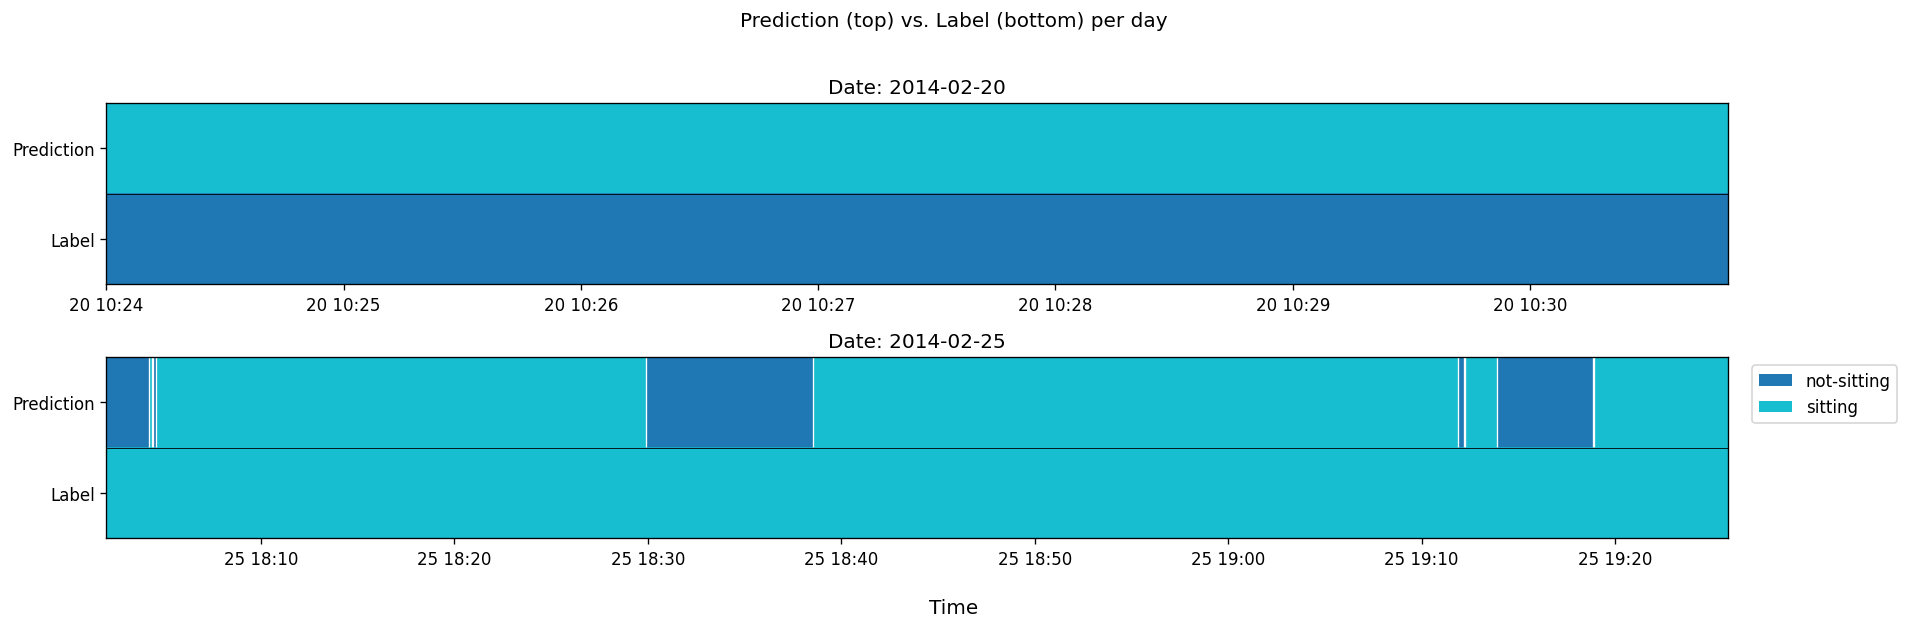

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
path = '/niddk-data-central/iWatch/submit_result/W/CHAP-FT/val_predictions/i0195A.csv'
df = pd.read_csv(path, parse_dates=['timestamp'])

# Map class names to ints and assign colors
class_names = sorted(set(df['prediction']).union(set(df['label'])))
class_to_int = {name: i for i, name in enumerate(class_names)}
colors = plt.get_cmap('tab10', len(class_names))

df['pred_int'] = df['prediction'].map(class_to_int)
df['label_int'] = df['label'].map(class_to_int)
df['date'] = df['timestamp'].dt.date

def plot_segments(ax, times, ints, ylow, yhigh, color_map):
    prev = ints[0]
    start = 0
    for i in range(1, len(ints)):
        if ints[i] != prev or i == len(ints) - 1:
            end = i if ints[i] != prev else i+1
            ax.fill_between(times[start:end], ylow, yhigh, color=color_map(prev), step='post')
            start = i
            prev = ints[i]

unique_dates = sorted(df['date'].unique())
n_dates = len(unique_dates)
fig, axs = plt.subplots(n_dates, 1, figsize=(16, 2.5*n_dates), sharex=False, dpi=120)

if n_dates == 1:
    axs = [axs]  # Ensure axs is always a list

for i, date in enumerate(unique_dates):
    ax = axs[i]
    subdf = df[df['date'] == date].reset_index(drop=True)
    plot_segments(ax, subdf['timestamp'], subdf['pred_int'], 1, 2, lambda i: colors(i))
    plot_segments(ax, subdf['timestamp'], subdf['label_int'], 0, 1, lambda i: colors(i))
    ax.axhline(1, color='k', lw=0.5)
    ax.set_yticks([0.5, 1.5])
    ax.set_yticklabels(['Label', 'Prediction'])
    ax.set_ylim(0, 2)
    ax.set_xlim(subdf['timestamp'].iloc[0], subdf['timestamp'].iloc[-1])
    ax.set_title(f'Date: {date}')

fig.supxlabel('Time')
fig.suptitle('Prediction (top) vs. Label (bottom) per day', y=1.02)

# Optional: add legend for the classes to the last subplot
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=colors(i), label=cls) for cls, i in class_to_int.items()]
axs[-1].legend(handles=legend_handles, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()


In [4]:
# Aniesh Metric
def compute_accuracy_from_confusion_matrix(cm):
    # True Positives (TP): Diagonal elements
    true_positive = np.diag(cm)

    # False Positives (FP): Column sum - TP
    false_positive = cm.sum(axis=0) - true_positive

    # False Negatives (FN): Row sum - TP
    false_negative = cm.sum(axis=1) - true_positive

    # True Negatives (TN): Total sum - (TP + FP + FN)
    total = cm.sum()
    true_negative = total - (true_positive + false_positive + false_negative)

    # Debug prints for each class
    for i in range(len(true_positive)):

        if true_negative[i] + false_positive[i] == 0:
            print(f"  ⚠️ No negative examples for class {i}")
        if true_positive[i] + false_negative[i] == 0:
            print(f"  ⚠️ No positive examples for class {i}")
        if true_negative[i] == 0 and false_positive[i] > 0:
            print(f"Class {i}:")
            print(f"  TP = {true_positive[i]}, FP = {false_positive[i]}, FN = {false_negative[i]}, TN = {true_negative[i]}")
            print(f"  ⚠️ Specificity for class {i} is 0 — all negative samples predicted as class {i}")
            print("\nFull Confusion Matrix:\n", cm)

    # Accuracy: Total correct predictions / Total samples
    accuracy = true_positive.sum() / total

    # Sensitivity (Recall): TP / (TP + FN)
    with np.errstate(divide='ignore', invalid='ignore'):
        sensitivity = np.divide(true_positive, true_positive + false_negative)
        sensitivity[np.isnan(sensitivity)] = 0

    # Specificity: TN / (TN + FP)
    with np.errstate(divide='ignore', invalid='ignore'):
        specificity = np.divide(true_negative, true_negative + false_positive)
        specificity[np.isnan(specificity)] = 0

    # Balanced Accuracy: Average of Sensitivity and Specificity
    balanced_accuracy = np.mean((sensitivity + specificity) / 2)

    return accuracy, balanced_accuracy

def compute_additional_metrics_from_confusion_matrix(cm):
    """
    Compute specificity, sensitivity, positive predictive value (PPV),
    and negative predictive value (NPV) from a multi-class confusion matrix.

    :param cm: NumPy array representing the confusion matrix (square matrix).
    :return: Dictionary containing computed metrics for each class.
    """
    # True Positives (TP): Diagonal elements
    true_positive = np.diag(cm)

    # False Positives (FP): Column sum - TP
    false_positive = cm.sum(axis=0) - true_positive

    # False Negatives (FN): Row sum - TP
    false_negative = cm.sum(axis=1) - true_positive

    # True Negatives (TN): Total sum - (TP + FP + FN)
    total = cm.sum()
    true_negative = total - (true_positive + false_positive + false_negative)

    # Compute metrics
    sensitivity = true_positive / (true_positive + false_negative)  # Recall
    specificity = true_negative / (true_negative + false_positive)
    ppv = true_positive / (true_positive + false_positive)  # Precision
    npv = true_negative / (true_negative + false_negative)
    f1_score = 2 * ppv * sensitivity / (ppv + sensitivity)

    # Handle division by zero
    sensitivity = np.nan_to_num(sensitivity)
    specificity = np.nan_to_num(specificity)
    ppv = np.nan_to_num(ppv)
    npv = np.nan_to_num(npv)
    f1_score = np.nan_to_num(f1_score)

    # Return metrics for each class
    return {
        "sensitivity": sensitivity.tolist(),
        "specificity": specificity.tolist(),
        "positive_predictive_value": ppv.tolist(),
        "negative_predictive_value": npv.tolist(),
        "f1_score": f1_score.tolist(),
    }


In [5]:
import pandas as pd
from sklearn.metrics import confusion_matrix, balanced_accuracy_score

# Load data
path = '/niddk-data-central/leo_workspace/iWatch-Validation/W/CHAP-FT/predictions/i0195A.csv'
df = pd.read_csv(path)

# Ensure the order and mapping
class_names = sorted(set(df['prediction']).union(set(df['label'])))
class_to_int = {name: i for i, name in enumerate(class_names)}

# Map to integer labels
y_pred = df['prediction'].map(class_to_int).values
y_true = df['label'].map(class_to_int).values

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))

# SKLearn metrics
print("Confusion matrix:\n", cm)

# Balanced accuracy
bal_acc = balanced_accuracy_score(y_true, y_pred)
print("Balanced accuracy:", bal_acc)

# Optionally, show with class labels
import pandas as pd
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
print("\nConfusion Matrix (with labels):")
print(cm_df)


Confusion matrix:
 [[  0  42]
 [ 99 405]]
Balanced accuracy: 0.4017857142857143

Confusion Matrix (with labels):
             not-sitting  sitting
not-sitting            0       42
sitting               99      405


In [7]:
import numpy as np
compute_accuracy_from_confusion_matrix(cm)

Class 1:
  TP = 405, FP = 42, FN = 99, TN = 0
  ⚠️ Specificity for class 1 is 0 — all negative samples predicted as class 1

Full Confusion Matrix:
 [[  0  42]
 [ 99 405]]


(0.7417582417582418, 0.4017857142857143)

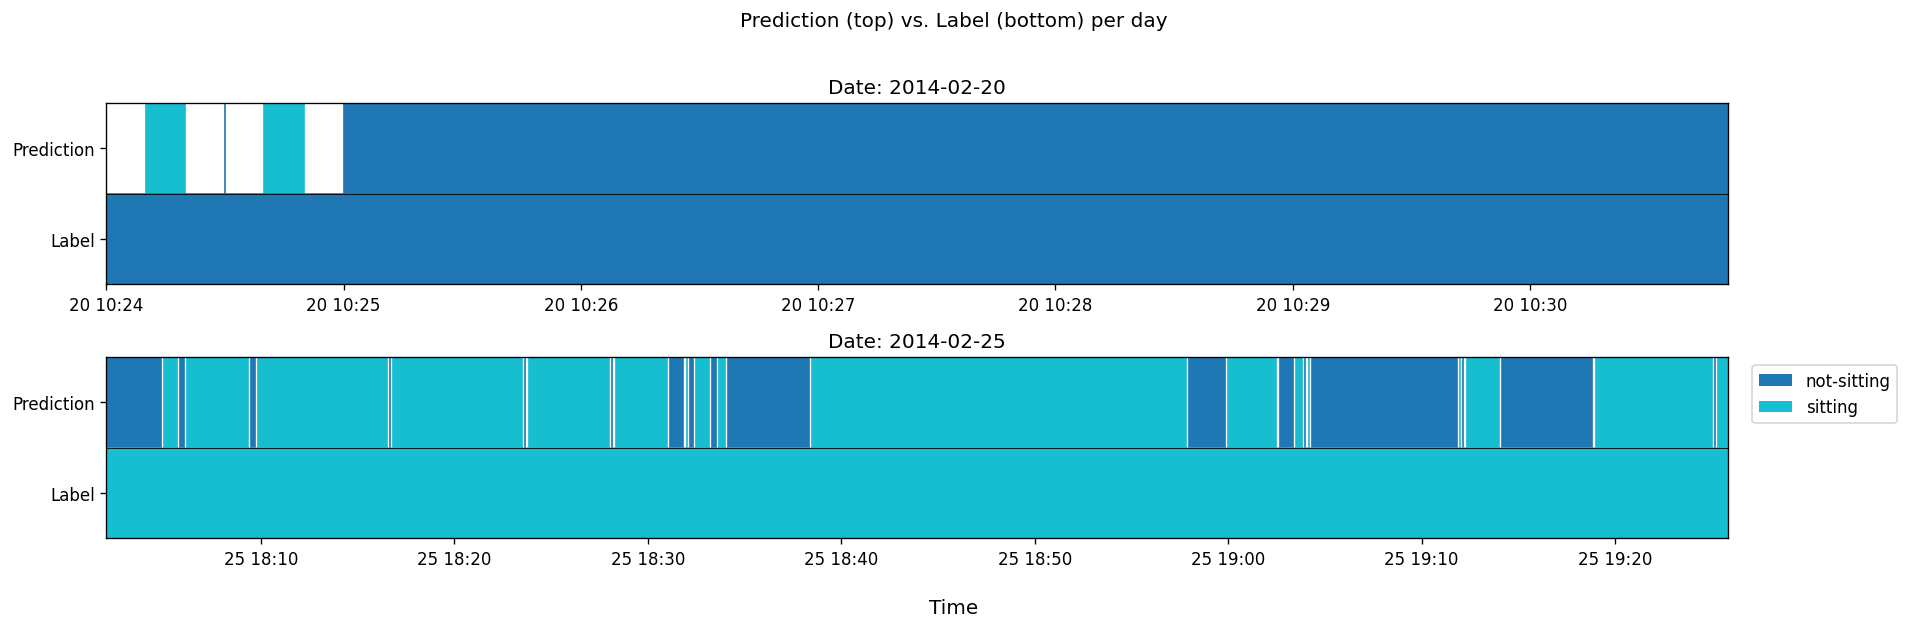

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
path = '/niddk-data-central/iWatch/submit_result/W/CHAP-ZS/val_predictions/i0195A.csv'
df = pd.read_csv(path, parse_dates=['timestamp'])

# Map class names to ints and assign colors
class_names = sorted(set(df['prediction']).union(set(df['label'])))
class_to_int = {name: i for i, name in enumerate(class_names)}
colors = plt.get_cmap('tab10', len(class_names))

df['pred_int'] = df['prediction'].map(class_to_int)
df['label_int'] = df['label'].map(class_to_int)
df['date'] = df['timestamp'].dt.date

def plot_segments(ax, times, ints, ylow, yhigh, color_map):
    prev = ints[0]
    start = 0
    for i in range(1, len(ints)):
        if ints[i] != prev or i == len(ints) - 1:
            end = i if ints[i] != prev else i+1
            ax.fill_between(times[start:end], ylow, yhigh, color=color_map(prev), step='post')
            start = i
            prev = ints[i]

unique_dates = sorted(df['date'].unique())
n_dates = len(unique_dates)
fig, axs = plt.subplots(n_dates, 1, figsize=(16, 2.5*n_dates), sharex=False, dpi=120)

if n_dates == 1:
    axs = [axs]  # Ensure axs is always a list

for i, date in enumerate(unique_dates):
    ax = axs[i]
    subdf = df[df['date'] == date].reset_index(drop=True)
    plot_segments(ax, subdf['timestamp'], subdf['pred_int'], 1, 2, lambda i: colors(i))
    plot_segments(ax, subdf['timestamp'], subdf['label_int'], 0, 1, lambda i: colors(i))
    ax.axhline(1, color='k', lw=0.5)
    ax.set_yticks([0.5, 1.5])
    ax.set_yticklabels(['Label', 'Prediction'])
    ax.set_ylim(0, 2)
    ax.set_xlim(subdf['timestamp'].iloc[0], subdf['timestamp'].iloc[-1])
    ax.set_title(f'Date: {date}')

fig.supxlabel('Time')
fig.suptitle('Prediction (top) vs. Label (bottom) per day', y=1.02)

# Optional: add legend for the classes to the last subplot
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=colors(i), label=cls) for cls, i in class_to_int.items()]
axs[-1].legend(handles=legend_handles, bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()


In [12]:
import pandas as pd
from sklearn.metrics import confusion_matrix, balanced_accuracy_score

# Load data
path = '/niddk-data-central/iWatch/submit_result/W/CHAP-ZS/val_predictions/i0195A.csv'
df = pd.read_csv(path)

# Ensure the order and mapping
class_names = sorted(set(df['prediction']).union(set(df['label'])))
class_to_int = {name: i for i, name in enumerate(class_names)}

# Map to integer labels
y_pred = df['prediction'].map(class_to_int).values
y_true = df['label'].map(class_to_int).values

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
print("Confusion matrix:\n", cm)

# Balanced accuracy
bal_acc = balanced_accuracy_score(y_true, y_pred)
print("Balanced accuracy:", bal_acc)

# Optionally, show with class labels
import pandas as pd
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
print("\nConfusion Matrix (with labels):")
print(cm_df)


Confusion matrix:
 [[ 38   4]
 [155 349]]
Balanced accuracy: 0.7986111111111112

Confusion Matrix (with labels):
             not-sitting  sitting
not-sitting           38        4
sitting              155      349


In [4]:
import pandas as pd

PRED_DIR = '/niddk-data-central/iWatch/submit_result/W/CHAP-ZS/val_predictions'
GT_H5    = '/niddk-data-central/iWatch/pre_processed_long_seg/W/10s_val.h5'
val_acc, val_balanced_acc, additional_metrics, per_subject_results = compute_metrics(PRED_DIR, GT_H5)


df = pd.DataFrame.from_dict(per_subject_results, orient='index').reset_index()
df = df.rename(columns={'index': 'subject_id'})
df[df['subject_id']=='i0195A'] 

All prediction rows matched ground truth.
Overall Accuracy: 0.6784, Balanced Accuracy: 0.7319
sensitivity: [0.6182370391298206, 0.8455045151158226]
specificity: [0.8455045151158226, 0.6182370391298206]
positive_predictive_value: [0.9175052410901468, 0.44347199341021415]
negative_predictive_value: [0.44347199341021415, 0.9175052410901468]
f1_score: [0.7387121276057051, 0.5817911657436174]


,subject_id,accuracy,balanced_accuracy,sensitivity,specificity,positive_predictive_value,negative_predictive_value,f1_score
19,i0195A,0.708791,0.798611,"[0.6924603174603174, 0.9047619047619048]","[0.9047619047619048, 0.6924603174603174]","[0.9886685552407932, 0.19689119170984457]","[0.19689119170984457, 0.9886685552407932]","[0.8144690781796966, 0.32340425531914896]"


In [16]:
import pandas as pd

PRED_DIR = '/niddk-data-central/iWatch/submit_result/H/CHAP-FT/val_predictions'
GT_H5    = '/niddk-data-central/iWatch/pre_processed_long_seg/H/10s_val.h5'
val_acc, val_balanced_acc, additional_metrics, per_subject_results = compute_metrics(PRED_DIR, GT_H5)


df = pd.DataFrame.from_dict(per_subject_results, orient='index').reset_index()
df = df.rename(columns={'index': 'subject_id'})
df[df['subject_id']=='i0195A'] 

All prediction rows matched ground truth.
Overall Accuracy: 0.9288, Balanced Accuracy: 0.9229
sensitivity: [0.9349811618449151, 0.9108259393795034]
specificity: [0.9108259393795034, 0.9349811618449151]
positive_predictive_value: [0.9683568822460451, 0.8275740797518351]
negative_predictive_value: [0.8275740797518351, 0.9683568822460451]
f1_score: [0.9513763943864699, 0.8672065465953547]


,subject_id,accuracy,balanced_accuracy,sensitivity,specificity,positive_predictive_value,negative_predictive_value,f1_score
19,i0195A,0.915751,0.954365,"[0.9087301587301587, 1.0]","[1.0, 0.9087301587301587]","[1.0, 0.4772727272727273]","[0.4772727272727273, 1.0]","[0.9521829521829522, 0.6461538461538462]"


In [6]:
import pandas as pd
weiwei_path = '/Users/leo/Desktop/DeepPostures_MAE/support_files/Archive/iWatch_CHAP1.0_W_ParticipantLevel_agree.csv'
weiwei_df = pd.read_csv(weiwei_path)
# only need balanced accuracy
weiwei_df

,OverALLAgree,Metrics,ID,nSegments,file
0,0.652660,Accuracy,i0004A,1,i0004A_CHAP_AllAdult_FULLpred_wl_nw_marked.csv
1,0.331365,Kappa,i0004A,1,i0004A_CHAP_AllAdult_FULLpred_wl_nw_marked.csv
2,0.646787,AccuracyLower,i0004A,1,i0004A_CHAP_AllAdult_FULLpred_wl_nw_marked.csv
3,0.658499,AccuracyUpper,i0004A,1,i0004A_CHAP_AllAdult_FULLpred_wl_nw_marked.csv
4,0.562546,Sensitivity,i0004A,1,i0004A_CHAP_AllAdult_FULLpred_wl_nw_marked.csv
...,...,...,...,...,...
610,0.701271,F1,i0378C,1,i0378C_CHAP_AllAdult_FULLpred_wl_nw_marked.csv
611,0.525086,Prevalence,i0378C,1,i0378C_CHAP_AllAdult_FULLpred_wl_nw_marked.csv
612,0.301775,Detection Rate,i0378C,1,i0378C_CHAP_AllAdult_FULLpred_wl_nw_marked.csv
613,0.335567,Detection Prevalence,i0378C,1,i0378C_CHAP_AllAdult_FULLpred_wl_nw_marked.csv


In [7]:
weiwei_df = weiwei_df[weiwei_df['Metrics'] == 'Balanced Accuracy']
weiwei_df = weiwei_df[['ID', 'OverALLAgree']]
weiwei_df

,ID,OverALLAgree
14,i0004A,0.685115
29,i0006A,0.494776
44,i0013A,0.568080
59,i0013B,0.743783
74,i0018A,0.734694
89,i0020A,0.813704
104,i0021A,0.781815
119,i0055A,0.679180
134,i0084B,0.722259
149,i0087A,0.672472


In [8]:
import os
import pandas as pd
from sklearn.metrics import balanced_accuracy_score

# Folder containing CSV files
folder = '/Users/leo/Desktop/DeepPostures_MAE/support_files/submit_result/W/CHAP-ZS/predictions'

# Get all CSV files in the folder
csv_files = [f for f in os.listdir(folder) if f.endswith('.csv')]

# To collect results
results = []

for fname in csv_files:
    fpath = os.path.join(folder, fname)
    df = pd.read_csv(fpath)
    # Get unique class names across pred and label for correct mapping
    class_names = sorted(set(df['prediction']).union(set(df['label'])))
    class_to_int = {name: i for i, name in enumerate(class_names)}
    y_pred = df['prediction'].map(class_to_int).values
    y_true = df['label'].map(class_to_int).values
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    results.append({'subject': fname.replace('.csv',''), 'balanced_accuracy': bal_acc})

# Create dataframe
results_df = pd.DataFrame(results)
print(results_df)


   subject  balanced_accuracy
0   i0355A           0.748571
1   i0197A           0.760069
2   i0206B           0.739589
3   i0089A           0.718640
4   i0084B           0.725977
5   i0378C           0.775336
6   i0006A           0.476296
7   i0303A           0.774091
8   i0138A           0.548800
9   i0021A           0.796818
10  i0125A           0.701168
11  i0109A           0.672932
12  i0294A           0.706432
13  i0282A           0.800631
14  i0295A           0.817966
15  i0344A           0.663742
16  i0094A           0.814907
17  i0325A           0.734754
18  i0124A           0.663871
19  i0173A           0.589225
20  i0020A           0.822809
21  i0127A           0.393695
22  i0170A           0.708877
23  i0238A           0.841380
24  i0193A           0.706156
25  i0184A           0.788932
26  i0055A           0.672532
27  i0167A           0.867556
28  i0018A           0.723950
29  i0262A           0.795481
30  i0013A           0.556228
31  i0087A           0.682418
32  i0357A

In [9]:
# Standardize column names for merging
results_df = results_df.rename(columns={'subject': 'ID'})
merged_df = pd.merge(results_df, weiwei_df, on='ID', how='inner')

print(merged_df)




        ID  balanced_accuracy  OverALLAgree
0   i0355A           0.748571      0.741292
1   i0197A           0.760069      0.736152
2   i0206B           0.739589      0.746963
3   i0089A           0.718640      0.719891
4   i0084B           0.725977      0.722259
5   i0378C           0.775336      0.751782
6   i0006A           0.476296      0.494776
7   i0303A           0.774091      0.761793
8   i0138A           0.548800      0.565707
9   i0021A           0.796818      0.781815
10  i0125A           0.701168      0.672749
11  i0109A           0.672932      0.696398
12  i0294A           0.706432      0.703151
13  i0282A           0.800631      0.788310
14  i0295A           0.817966      0.801533
15  i0344A           0.663742      0.641045
16  i0094A           0.814907      0.811020
17  i0325A           0.734754      0.751531
18  i0124A           0.663871      0.675633
19  i0173A           0.589225      0.585591
20  i0020A           0.822809      0.813704
21  i0127A           0.393695   

In [10]:
# check if the values are the same
merged_df['same'] = merged_df['balanced_accuracy'].round(4) == merged_df['OverALLAgree'].round(4)
print(merged_df[['ID', 'balanced_accuracy', 'OverALLAgree', 'same']])
print("All values match:", merged_df['same'].all())

        ID  balanced_accuracy  OverALLAgree   same
0   i0355A           0.748571      0.741292  False
1   i0197A           0.760069      0.736152  False
2   i0206B           0.739589      0.746963  False
3   i0089A           0.718640      0.719891  False
4   i0084B           0.725977      0.722259  False
5   i0378C           0.775336      0.751782  False
6   i0006A           0.476296      0.494776  False
7   i0303A           0.774091      0.761793  False
8   i0138A           0.548800      0.565707  False
9   i0021A           0.796818      0.781815  False
10  i0125A           0.701168      0.672749  False
11  i0109A           0.672932      0.696398  False
12  i0294A           0.706432      0.703151  False
13  i0282A           0.800631      0.788310  False
14  i0295A           0.817966      0.801533  False
15  i0344A           0.663742      0.641045  False
16  i0094A           0.814907      0.811020  False
17  i0325A           0.734754      0.751531  False
18  i0124A           0.663871  